Required imports for model.

In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

Loading training dataset and splitting it into features 'X' (destination coordiantes, crime score, public safety score and crime severity) and target 'y' (safety scores).

In [2]:
training_set = pd.read_csv("C:\\Users\\loisp\\Documents\\Year3\\Dissertation\\Proutect\\Proutect\\csv-json-files\\training_set.csv")

X = training_set.drop('Safety Score', axis=1)
y = training_set['Safety Score']
print(X)
print(y)

      Latitude  Longitude  Year  Crime Score  Crime Severity Score  \
0    52.295042  -1.570058  2021     0.017970              0.633333   
1    52.295042  -1.562762  2021     0.011809              0.663768   
2    52.295042  -1.555381  2021     0.010440              0.645902   
3    52.295042  -1.548171  2021     0.020195              0.519828   
4    52.295042  -1.540875  2021     0.083176              0.558974   
..         ...        ...   ...          ...                   ...   
226  52.268551  -1.526155  2023     0.010580              0.652542   
227  52.268551  -1.518688  2023     0.005643              0.715625   
228  52.268551  -1.511564  2023     0.000529              1.000000   
229  52.268551  -1.504140  2023     0.000000              0.000000   
230  52.268551  -1.497617  2023     0.000000              0.000000   

     Public Space Score  
0              0.000000  
1              0.000000  
2              0.003115  
3              0.006231  
4              0.015576  
.. 

Split data into training/test set.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [4]:
regressor = RandomForestRegressor(n_estimators=100, random_state=42, oob_score = True)
regressor.fit(X_train, y_train)

RandomForestRegressor(oob_score=True, random_state=42)

In [5]:
from sklearn.metrics import mean_squared_error

# Predicting on the test set
y_pred = regressor.predict(X_test)


print(y_pred)

# Calculating the Root Mean Squared Error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse}")

[46.43309761 64.36473875 65.         38.3951412  40.86827468 34.3338338
 41.62512283 36.79645524 43.76670508 53.19787154 55.74390848 39.14253574
 31.22234938 47.00043981 65.         52.15923888 47.21730759 53.6524655
 51.52301406 65.         33.75374629 65.         49.4505932  44.97555866
 49.58416548 47.2626711  55.76211609 46.96272227 44.97652141 75.2317757
 34.20326163 42.17677663 47.4960856  18.44853276 40.71627036 51.30276689
 41.93084908 38.24371303 44.24906727 33.86376919 41.15093676 48.04544555
 64.36473875 54.18674097 30.47162093 40.48911813 59.23359651]
RMSE: 1.867167854715209


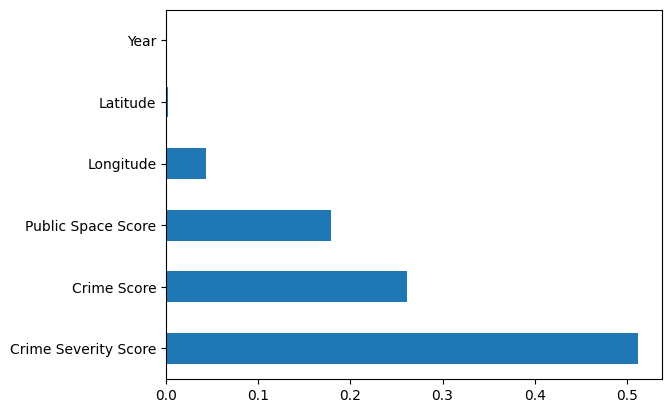

In [6]:
feature_importances = pd.Series(regressor.feature_importances_, index=X.columns)
feature_importances.nlargest(10).plot(kind='barh')  # Top 10 features
plt.show()

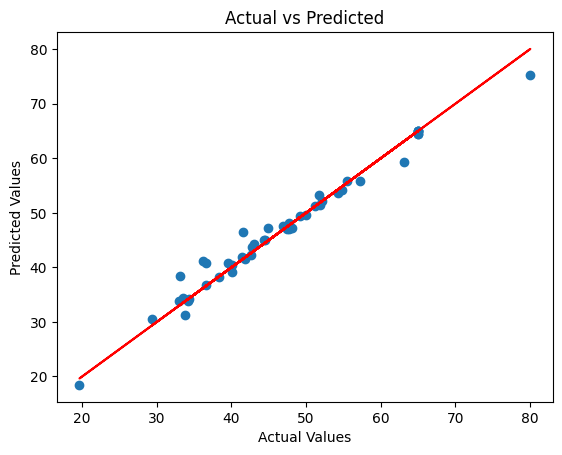

In [7]:
import matplotlib.pyplot as plt

# Scatter plot for actual vs predicted values
plt.scatter(x=y_test, y=y_pred)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted')
plt.plot(y_test, y_test, color='red')  # Line for perfect predictions
plt.show()